In [1]:
import sys
import torch
import polars as pl

from modeling_module.data_loader.MultiPartDataModule import MultiPartDataModule

'''
pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
https://developer.nvidia.com/cuda-12-8-0-download-archive
'''

MAC_DIR = '/Users/igwanhyeong/PycharmProjects/data_research/raw_data/'
WINDOW_DIR = 'C:/Users/USER/PycharmProjects/research/raw_data/'

if sys.platform == 'win32':
    DIR = WINDOW_DIR
    print(torch.cuda.is_available())
    print(torch.cuda.device_count())
    print(torch.version.cuda)
    print(torch.__version__)
    print(torch.cuda.get_device_name(0))
    print(torch.__version__)
else:
    DIR = MAC_DIR

True
1
12.8
2.9.0.dev20250716+cu128
NVIDIA GeForce RTX 5080
2.9.0.dev20250716+cu128


In [2]:
target_dyn_demand_weekly = pl.read_parquet(DIR + 'target_dyn_demand_weekly.parquet').sort(['oper_part_no', 'demand_dt'])
target_dyn_demand_weekly

oper_part_no,demand_dt,demand_qty
str,i64,f64
"""0001-1001""",201811,5.0
"""0001-1001""",201847,7.0
"""0001-1001""",202005,20.0
"""0001-1001""",202006,100.0
"""0001-1001""",202010,2.0
…,…,…
"""ZZ90239""",202043,1.0
"""ZZ90239""",202145,1.0
"""ZZ90239""",202325,1.0


In [3]:
from modeling_module.models.PatchTST.supervised.backbone import SupervisedBackbone
from modeling_module.models.PatchTST.common.configs import PatchTSTConfigWeekly

cfg = PatchTSTConfigWeekly(
    c_in=1,
    target_dim=1,
    lookback=54,
    horizon=27,
    patch_len=4,
    stride=2,
)

model = SupervisedBackbone(cfg)
x = torch.randn(8, cfg.c_in, cfg.lookback)
out = model(x)

print(out.shape)  # [8, L_tok, d_model]

torch.Size([8, 26, 128])


In [4]:
plan_yyyymm = 201811
lookback = 54
horizon = 27

data_module = MultiPartDataModule(
    target_dyn_demand_weekly.sort(['oper_part_no', 'demand_dt']),
    lookback = lookback,
    horizon = horizon,
    batch_size = 64,
    val_ratio = 0.2,
    is_running = True
)

train_loader = data_module.get_train_loader()
val_loader = data_module.get_val_loader()

In [5]:
from modeling_module.training.model_trainers.total_train import run_total_train_monthly

mode_dict = run_total_train_monthly(
    train_loader,
    val_loader,
    lookback = lookback,
    horizon = horizon,
)

PatchMixer Base


C:\Users\USER\python\py312\Lib\site-packages\torch\nn\modules\conv.py:366: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1028.)
  return F.conv1d(


Epoch 1/1 | LR 0.000976 | Train 36.699039 | Val 36.369261
PatchMixer Quantile
Epoch 1/1 | LR 0.000976 | Train 16.201982 | Val 15.943317
Titan Base
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
Epoch 1/1 | LR 0.000976 | Train 87.772633 | Val 82.468384
Titan LMM
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN loss. step skipped.
[Warn] NaN

In [6]:
from modeling_module.utils.checkpoint import save_model_dict, load_model_dict
from modeling_module.utils.exogenous_utils import calendar_cb
from modeling_module.models.PatchTST.common.configs import PatchTSTConfigMonthly
from modeling_module.models.Titan.common.configs import TitanConfigMonthly, TitanConfigPatchMonthly
from modeling_module.models.PatchMixer.common.configs import PatchMixerConfigMonthly

save_dir = DIR + 'fit/20251102_running'
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

pm_base_config = PatchMixerConfigMonthly(
        device = device,
        loss_mode = 'point',
        point_loss = 'mae'
    )

pm_quantile_config = PatchMixerConfigMonthly(
    device = device,
    loss_mode = 'quantile',
    quantiles = (0.1, 0.5, 0.9)
)

ti_config = TitanConfigMonthly(
        device = device,
        loss_mode = 'point',
        point_loss = 'mae'
    )

ti_patch_config = TitanConfigPatchMonthly(
    device = device,
    loss_mode = 'point',
    point_loss = 'mae'
)

pt_config = PatchTSTConfigMonthly(
        device = device,
        loss_mode = 'auto',
        quantiles = (0.1, 0.5, 0.9)
    )

cfg_map = {
    "PatchMixer Base": pm_base_config,
    "PatchMixer Quantile": pm_quantile_config,
    "Titan Base": ti_config,
    "Titan LMM": ti_config,
    "Titan Seq2Seq": ti_config,
    "Titan Patch": ti_patch_config,
    "PatchTST Base": pt_config,
    "PatchTST Quantile": pt_config
}

builder_key_by_name = {
  "PatchMixer Base": "patchmixer_base",
  "PatchMixer Quantile": "patchmixer_quantile",
  "Titan Base": "titan_base",
  "Titan LMM": "titan_lmm",
  "Titan Seq2Seq": "titan_seq2seq",
  "Titan Patch": "titan_patch",
  "PatchTST Base": "patchtst_base",
  "PatchTST Quantile": "patchtst_quantile",
}
save_index = save_model_dict(mode_dict, save_dir, cfg_by_name = cfg_map, builder_key_by_name=builder_key_by_name)

# Load
from modeling_module.models.model_builder import (
    build_patch_mixer_base, build_patch_mixer_quantile,
    build_titan_base, build_titan_lmm, build_titan_seq2seq,
    build_patchTST_base, build_patchTST_quantile, build_titan_patch,
)

builders = {
    "patchmixer_base": lambda cfg: build_patch_mixer_base(cfg or PatchMixerConfigMonthly()),
    "patchmixer_quantile": lambda cfg: build_patch_mixer_quantile(cfg or PatchMixerConfigMonthly()),
    "titan_base": lambda cfg: build_titan_base(cfg or TitanConfigMonthly()),
    "titan_lmm": lambda cfg: build_titan_lmm(cfg or TitanConfigMonthly()),
    "titan_seq2seq": lambda cfg: build_titan_seq2seq(cfg or TitanConfigMonthly()),
    'titan_patch': lambda cfg: build_titan_patch(cfg or TitanConfigPatchMonthly()),
    "patchtst_base": lambda cfg: build_patchTST_base(cfg or PatchTSTConfigMonthly()),
    "patchtst_quantile": lambda cfg: build_patchTST_quantile(cfg or PatchTSTConfigMonthly()),
}
loaded = load_model_dict(save_dir, builders, device = device)



[load] patchmixer_base ← C:/Users/USER/PycharmProjects/research/raw_data/fit/20251102_running\patchmixer_base.pt
[load] patchmixer_quantile ← C:/Users/USER/PycharmProjects/research/raw_data/fit/20251102_running\patchmixer_quantile.pt
[load] titan_base ← C:/Users/USER/PycharmProjects/research/raw_data/fit/20251102_running\titan_base.pt
[load] titan_lmm ← C:/Users/USER/PycharmProjects/research/raw_data/fit/20251102_running\titan_lmm.pt
[load] titan_seq2seq ← C:/Users/USER/PycharmProjects/research/raw_data/fit/20251102_running\titan_seq2seq.pt
[load] titan_patch ← C:/Users/USER/PycharmProjects/research/raw_data/fit/20251102_running\titan_patch.pt
[load] patchtst_base ← C:/Users/USER/PycharmProjects/research/raw_data/fit/20251102_running\patchtst_base.pt
[load] patchtst_quantile ← C:/Users/USER/PycharmProjects/research/raw_data/fit/20251102_running\patchtst_quantile.pt


In [7]:
model = loaded["patchtst_base"].to(device).eval()
x1 = next(iter(val_loader))[0][:1].to(device)   # [1, L, C] or [1, L]

# (A) 직접 forward
with torch.no_grad():
    yA = model(x1)
    # dict/quantile 형태면 중앙값을 뽑도록 해석
    if isinstance(yA, dict):
        yA = yA.get("point", yA.get("q"))
        if yA.dim() == 3:  # [B,H,Q]
            yA = yA[..., 1]  # q50
    if yA.dim() == 3:       # [B,H,1] 등
        yA = yA.squeeze(-1)
    if yA.dim() == 1:
        yA = yA.view(1, -1)

# (B) 포캐스터 경유
from modeling_module.training.forecaster import DMSForecaster
f = DMSForecaster(model, target_channel=0, future_exo_cb=None)
with torch.no_grad():
    yB = f.forecast_DMS_to_IMS(x_init=x1, horizon=yA.size(1), device=device, extend="ims")

print("forward vs forecaster MSE:", float(((yA - yB)**2).mean()))
print("yA min/max/mean:", float(yA.min()), float(yA.max()), float(yA.mean()))
print("yB min/max/mean:", float(yB.min()), float(yB.max()), float(yB.mean()))

[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.0904527, first5=[0.686527, -0.380436, -0.387187, -0.237667, -0.144801]
[FCAST-DBG] DMS step=0: raw_n=0.686527
[FCAST-DBG] DMS step=1: raw_n=-0.380436
[FCAST-DBG] DMS step=2: raw_n=-0.387187
[FCAST-DBG] DMS step=3: raw_n=-0.237667
[FCAST-DBG] DMS step=4: raw_n=-0.144801
[FCAST-DBG] DONE: H=27, var=21.523, first5=[26.8994, 6.63999, 6.52836, 9.41864, 11.2831]
forward vs forecaster MSE: 160.16964721679688
yA min/max/mean: -0.8337857723236084 0.6865268349647522 -0.08828097581863403
yB min/max/mean: 2.861513137817383 26.899444580078125 11.826562881469727


[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.0854932, first5=[5.37878, 6.2069, 5.91991, 6.34241, 5.91592]
[FCAST-DBG] DMS step=0: raw_n=5.37878
[FCAST-DBG] DMS step=1: raw_n=6.2069
[FCAST-DBG] DMS step=2: raw_n=5.91991
[FCAST-DBG] DMS step=3: raw_n=6.34241
[FCAST-DBG] DMS step=4: raw_n=5.91592
[FCAST-DBG] DONE: H=27, var=0.0854932, first5=[5.37878, 6.2069, 5.91991, 6.34241, 5.91592]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=1.36483 q50=8.79846 q90=105.175
[Q-IMS][PatchMixer QuantileModel] t=1 q10=1.40423 q50=9.17716 q90=111.412
[Q-IMS][PatchMixer QuantileModel] t=2 q10=1.34252 q50=8.60005 q90=101.968
[Q-IMS][PatchMixer QuantileModel] t=3 q10=1.30035 q50=8.17094 q90=94.8994
[Q-IMS][PatchMixer QuantileModel] t=4 q10=1.20883 q50=7.22811 q90=79.4791
[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.000807077, first5=[0.818068, 0.820136, 0.837203, 0.853045, 0.84779]
[FCAST-DBG] DMS step=0: raw_n=0.818068
[FCAST-DBG] DMS step=1: raw_n=0.820136
[FCAST-DBG] DMS step=2: raw_n=0.837203
[FCAST-DBG] DMS step=3: 

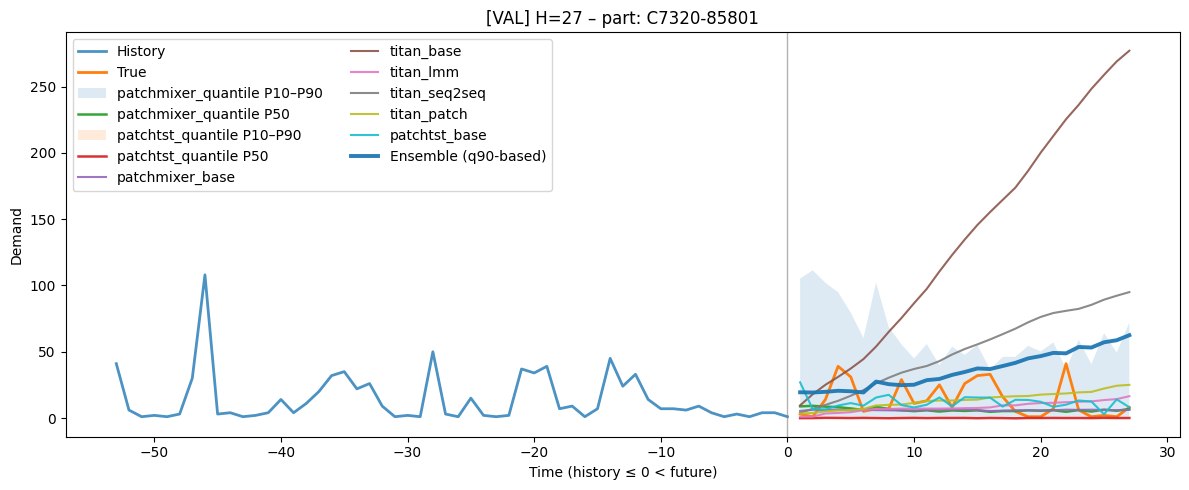

[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.0598768, first5=[5.15185, 5.17006, 4.89332, 5.44787, 5.41935]
[FCAST-DBG] DMS step=0: raw_n=5.15185
[FCAST-DBG] DMS step=1: raw_n=5.17006
[FCAST-DBG] DMS step=2: raw_n=4.89332
[FCAST-DBG] DMS step=3: raw_n=5.44787
[FCAST-DBG] DMS step=4: raw_n=5.41935
[FCAST-DBG] DONE: H=27, var=0.0598768, first5=[5.15185, 5.17006, 4.89332, 5.44787, 5.41935]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=1.08397 q50=5.13892 q90=43.8251
[Q-IMS][PatchMixer QuantileModel] t=1 q10=1.14715 q50=6.32104 q90=64.1491
[Q-IMS][PatchMixer QuantileModel] t=2 q10=1.05764 q50=4.7948 q90=38.4009
[Q-IMS][PatchMixer QuantileModel] t=3 q10=1.13605 q50=6.17903 q90=61.9723
[Q-IMS][PatchMixer QuantileModel] t=4 q10=1.07737 q50=5.10943 q90=43.5685
[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.000827003, first5=[0.863577, 0.870058, 0.888784, 0.906083, 0.899769]
[FCAST-DBG] DMS step=0: raw_n=0.863577
[FCAST-DBG] DMS step=1: raw_n=0.870058
[FCAST-DBG] DMS step=2: raw_n=0.888784
[FCAST-DBG] DMS step=

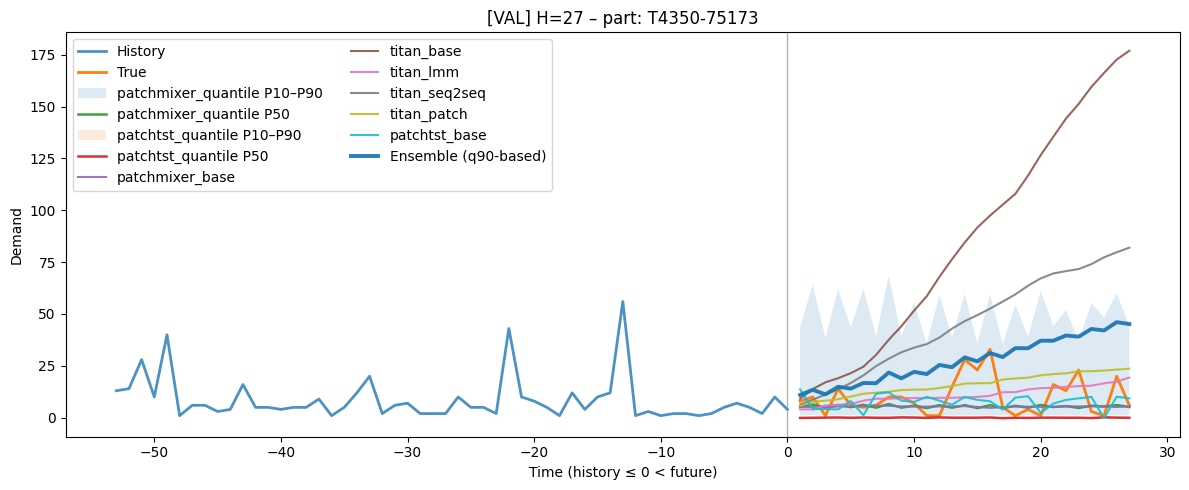

[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.124477, first5=[5.8019, 4.9872, 4.41347, 4.88428, 5.01511]
[FCAST-DBG] DMS step=0: raw_n=5.8019
[FCAST-DBG] DMS step=1: raw_n=4.9872
[FCAST-DBG] DMS step=2: raw_n=4.41347
[FCAST-DBG] DMS step=3: raw_n=4.88428
[FCAST-DBG] DMS step=4: raw_n=5.01511
[FCAST-DBG] DONE: H=27, var=0.124477, first5=[5.8019, 4.9872, 4.41347, 4.88428, 5.01511]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=1.0428 q50=4.49298 q90=33.0712
[Q-IMS][PatchMixer QuantileModel] t=1 q10=1.04652 q50=4.19811 q90=27.434
[Q-IMS][PatchMixer QuantileModel] t=2 q10=1.03408 q50=4.31563 q90=29.9973
[Q-IMS][PatchMixer QuantileModel] t=3 q10=1.03609 q50=4.35592 q90=30.6853
[Q-IMS][PatchMixer QuantileModel] t=4 q10=1.03649 q50=4.28476 q90=29.3456
[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.0008998, first5=[1.00321, 1.02137, 1.04395, 1.06415, 1.05694]
[FCAST-DBG] DMS step=0: raw_n=1.00321
[FCAST-DBG] DMS step=1: raw_n=1.02137
[FCAST-DBG] DMS step=2: raw_n=1.04395
[FCAST-DBG] DMS step=3: raw_n=1.06415
[F

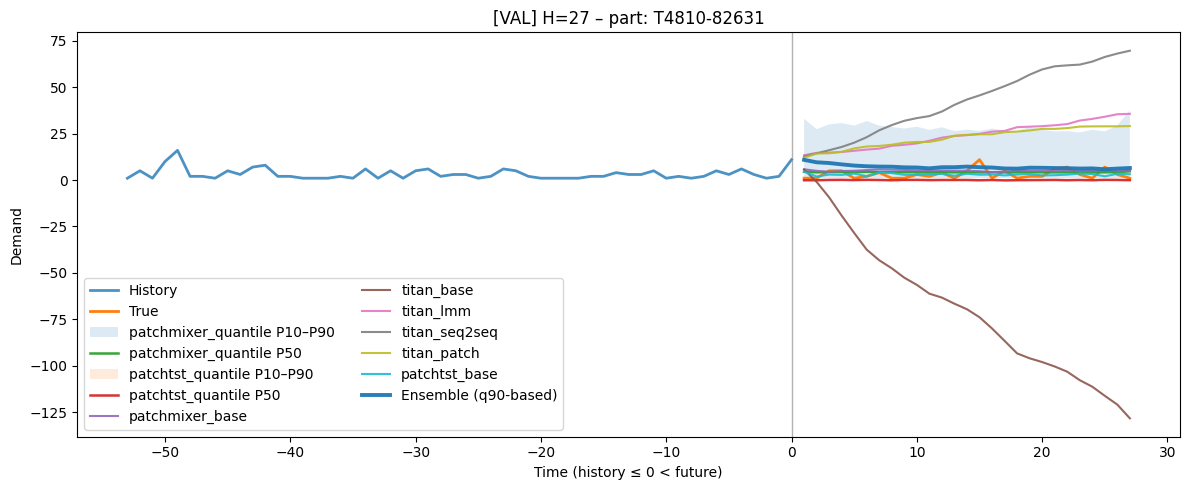

[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.0379566, first5=[3.68311, 3.72274, 3.36487, 3.79977, 3.57934]
[FCAST-DBG] DMS step=0: raw_n=3.68311
[FCAST-DBG] DMS step=1: raw_n=3.72274
[FCAST-DBG] DMS step=2: raw_n=3.36487
[FCAST-DBG] DMS step=3: raw_n=3.79977
[FCAST-DBG] DMS step=4: raw_n=3.57934
[FCAST-DBG] DONE: H=27, var=0.0379566, first5=[3.68311, 3.72274, 3.36487, 3.79977, 3.57934]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=1.07534 q50=4.1654 q90=25.882
[Q-IMS][PatchMixer QuantileModel] t=1 q10=1.06312 q50=4.17045 q90=26.3116
[Q-IMS][PatchMixer QuantileModel] t=2 q10=1.0672 q50=4.16656 q90=26.0991
[Q-IMS][PatchMixer QuantileModel] t=3 q10=1.05647 q50=4.16557 q90=26.4743
[Q-IMS][PatchMixer QuantileModel] t=4 q10=1.07223 q50=4.16568 q90=25.9581
[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.000844407, first5=[0.900121, 0.909776, 0.92956, 0.94783, 0.940881]
[FCAST-DBG] DMS step=0: raw_n=0.900121
[FCAST-DBG] DMS step=1: raw_n=0.909776
[FCAST-DBG] DMS step=2: raw_n=0.92956
[FCAST-DBG] DMS step=3: ra

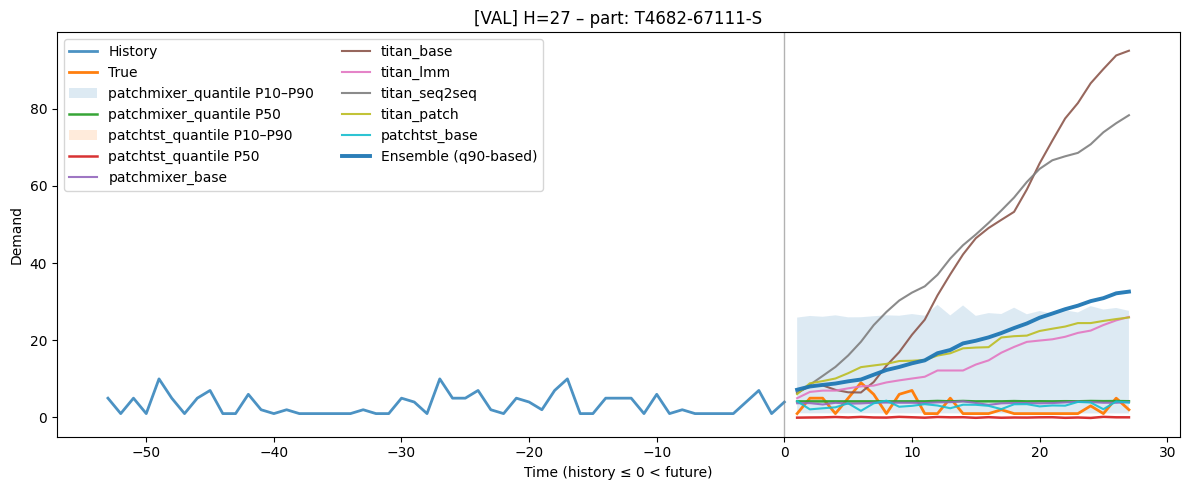

[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.553294, first5=[6.99712, 7.91778, 7.46926, 6.98573, 6.27061]
[FCAST-DBG] DMS step=0: raw_n=6.99712
[FCAST-DBG] DMS step=1: raw_n=7.91778
[FCAST-DBG] DMS step=2: raw_n=7.46926
[FCAST-DBG] DMS step=3: raw_n=6.98573
[FCAST-DBG] DMS step=4: raw_n=6.27061
[FCAST-DBG] DONE: H=27, var=0.553294, first5=[6.99712, 7.91778, 7.46926, 6.98573, 6.27061]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=1.06965 q50=4.97166 q90=41.2944
[Q-IMS][PatchMixer QuantileModel] t=1 q10=1.08443 q50=5.15972 q90=44.2132
[Q-IMS][PatchMixer QuantileModel] t=2 q10=1.13056 q50=6.0119 q90=58.7969
[Q-IMS][PatchMixer QuantileModel] t=3 q10=1.18692 q50=6.70762 q90=70.026
[Q-IMS][PatchMixer QuantileModel] t=4 q10=1.19344 q50=6.77493 q90=71.053
[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.000937694, first5=[1.06655, 1.08981, 1.11457, 1.13528, 1.12927]
[FCAST-DBG] DMS step=0: raw_n=1.06655
[FCAST-DBG] DMS step=1: raw_n=1.08981
[FCAST-DBG] DMS step=2: raw_n=1.11457
[FCAST-DBG] DMS step=3: raw_n=1.1

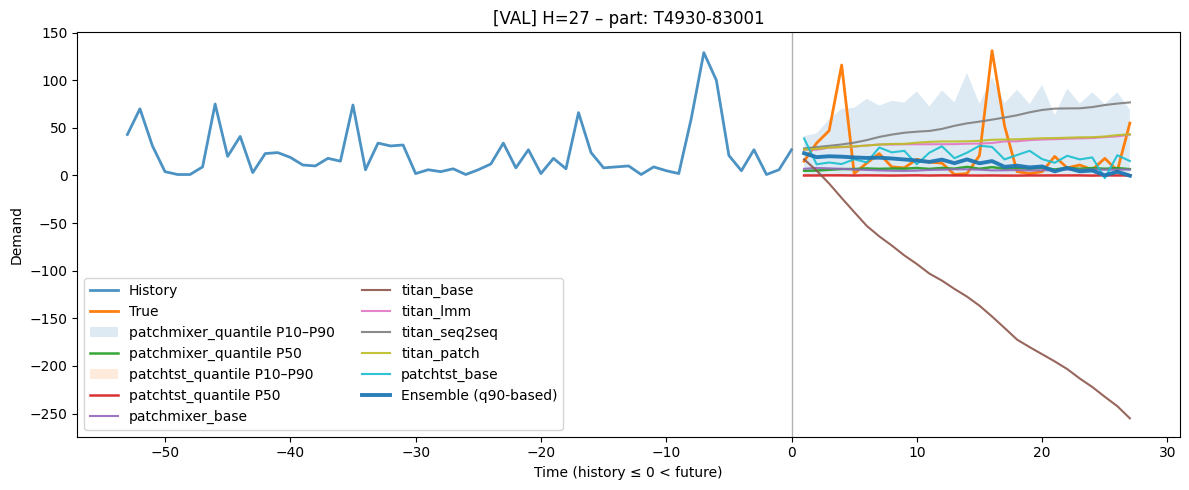

In [8]:
%load_ext autoreload
%autoreload 2

import importlib, modeling_module.utils.plot_utils as pu
import modeling_module.training.forecaster as fo
importlib.reload(pu)
importlib.reload(fo)

def my_exo_cb(start_idx: int, Hm: int, device="cuda"):
    # exo_dim = 2 (sin, cos)
    return fo.make_calendar_exo(start_idx, Hm, period=52, device=device)

pu.plot_27w(
    models=loaded,           # {"PatchMixer": pm_model, "Titan": ti_model, ...}
    loader=val_loader,       # (xb, yb[, part_ids])
    device="cuda",
    mode="val",              # ← 검증 모드
    max_plots=5,
    out_dir=None,
    show=True,
    future_exo_cb=my_exo_cb
)

In [9]:
# plan_yyyyww 기준으로 과거 히스토리 + 27주 예측을 그림
# pu.plot_27w(
#     models=loaded,
#     loader=inference_loader,  # (xb, part_ids)
#     device="cuda",
#     mode="infer",             # ← 추론 모드
#     plan_yyyyww=202544,       # 앵커 주차(예: 2025년 44주)
#     max_plots=10,
#     out_dir=None,
#     show=True,
#     future_exo_cb=my_exo_cb,
#     # 필요하면 GT를 불러오는 콜백(옵션)
#     truth_cb=None            # 또는 truth_cb(part_id, plan_dt, H=27, 'week') -> np.ndarray
# )

In [10]:
# pu.plot_120m(
#     models=loaded,
#     loader=val_loader,       # (xb, yb[, part_ids])
#     device="cuda",
#     mode="val",
#     max_plots=5,
#     out_dir=None,
#     show=True,
#     future_exo_cb=my_exo_cb
# )

In [11]:
# pu.plot_120m(
#     models=loaded,
#     loader=inference_loader,  # (xb, part_ids)
#     device="cuda",
#     mode="infer",
#     plan_yyyymm=202510,       # 앵커 월(예: 2025년 10월)
#     max_plots=10,
#     out_dir=None,
#     show=True,
#     future_exo_cb=my_exo_cb,
#     # 필요하면 월 단위 GT 조회 콜백
#     truth_cb=None            # 또는 truth_cb(part_id, plan_dt, H=120, 'month') -> np.ndarray
# )